<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 8, accumulation steps = 1 (effective batch size ≈ 8, tuned value = 8)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
[InceptionNet v3] Epoch   1/100 | LR: 2.85e-04 | train loss 1.4292 acc 0.616 | val loss 0.6192 acc 0.753 *


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
[InceptionNet v3] Epoch   2/100 | LR: 2.85e-04 | train loss 1.1723 acc 0.718 | val loss 0.6594 acc 0.735


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


...

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
[InceptionNet v3] Epoch  13/100 | LR: 2.85e-04 | train loss 0.8283 acc 0.805 | val loss 0.6684 acc 0.694


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
[InceptionNet v3] Epoch  14/100 | LR: 2.85e-04 | train loss 0.8492 acc 0.787 | val loss 0.5639 acc 0.729


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864


Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
[InceptionNet v3] Epoch  15/100 | LR: 2.85e-04 | train loss 0.8602 acc 0.776 | val loss 0.6690 acc 0.741

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 15.

[InceptionNet v3] Resto

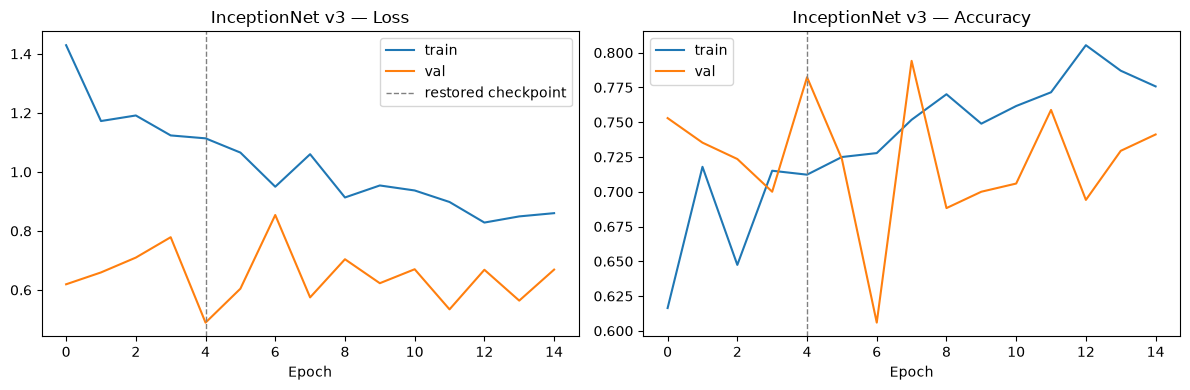

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 709 | Val: 170 | Test: 864
[InceptionNet v3] Test accuracy: 0.627


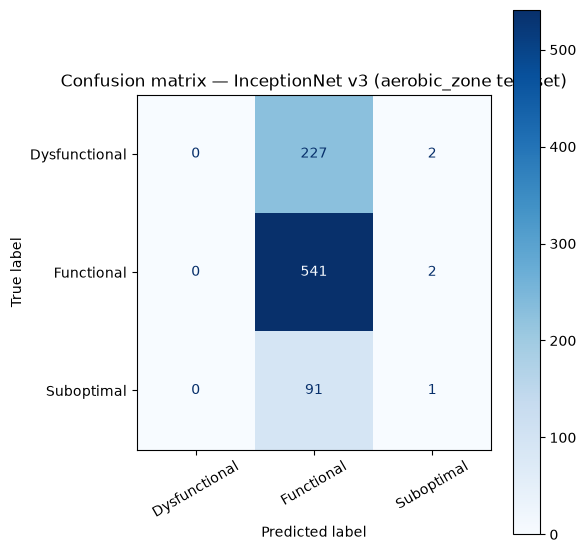

               precision    recall  f1-score   support

Dysfunctional      0.000     0.000     0.000       229
   Functional      0.630     0.996     0.772       543
   Suboptimal      0.200     0.011     0.021        92

     accuracy                          0.627       864
    macro avg      0.277     0.336     0.264       864
 weighted avg      0.417     0.627     0.487       864



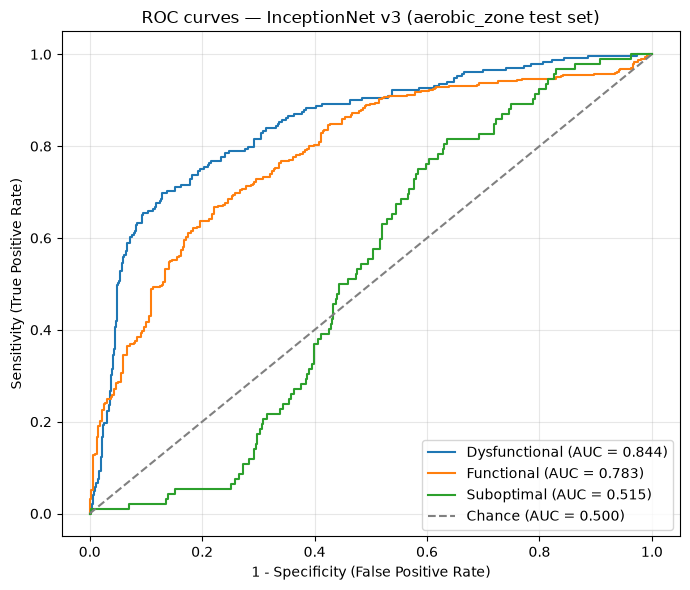

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.844
  Functional     : 0.783
  Suboptimal     : 0.515

Mean AUC (over 3/3 classes with test examples): 0.714


(np.float64(0.6273148148148148),
 {'Dysfunctional': 0.8443076711480932,
  'Functional': 0.7834575423257202,
  'Suboptimal': 0.5152061275061951})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/aerobic_zone_pad_aug/results_aerobic_zone_inception_v3_Waterval.pkl
Saved model weights to ../models/pad/aerobic_zone_inception_v3_cnn.pt
